In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../beam_search_summary.csv")
df

,dataset,beam_width,num_results,avg_edges,avg_edges_99,avg_edges_90,train_recall_G,train_recall_99,train_recall_90,train_seen_G,...,train_expanded_90,test_recall_G,test_recall_99,test_recall_90,test_seen_G,test_seen_99,test_seen_90,test_expanded_G,test_expanded_99,test_expanded_90
0,mnist,150,100,19.637517,7.861250,3.650017,0.98845,0.97094,0.73637,1782.688,...,186.634,0.996136,0.971231,0.728642,1790.5712,709.0100,451.9446,154.9676,159.5905,184.9738
1,fashion_mnist,150,100,13.551550,4.864417,2.753150,0.98908,0.93524,0.63641,1391.436,...,188.018,0.997185,0.935218,0.638319,1428.2186,576.3314,421.7619,154.0614,157.9326,187.2186
2,coco_t2i,150,100,28.588549,10.267215,4.136238,0.99376,0.97508,0.78263,2877.783,...,192.507,0.842102,0.420184,0.097264,3055.5862,1285.0230,671.1678,155.5828,175.3482,215.0878
3,coco_i2i,150,100,28.588549,10.267215,4.136238,0.99362,0.97318,0.74423,2970.254,...,194.069,0.992881,0.970592,0.742975,2946.3933,1098.8985,634.9407,153.6982,158.3530,194.3471


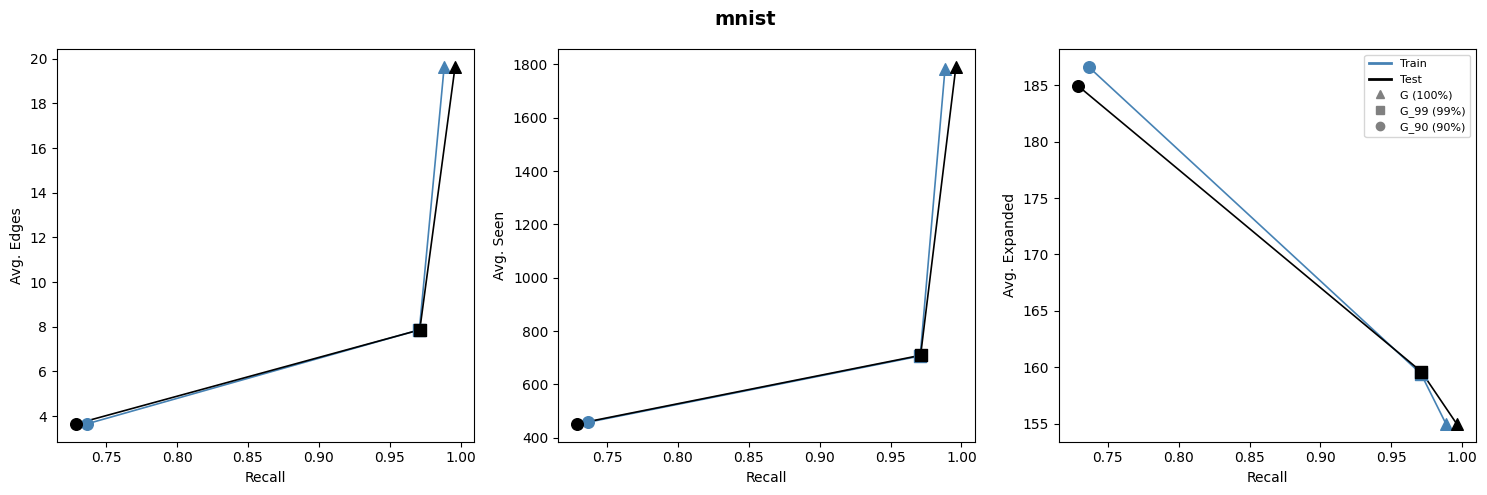

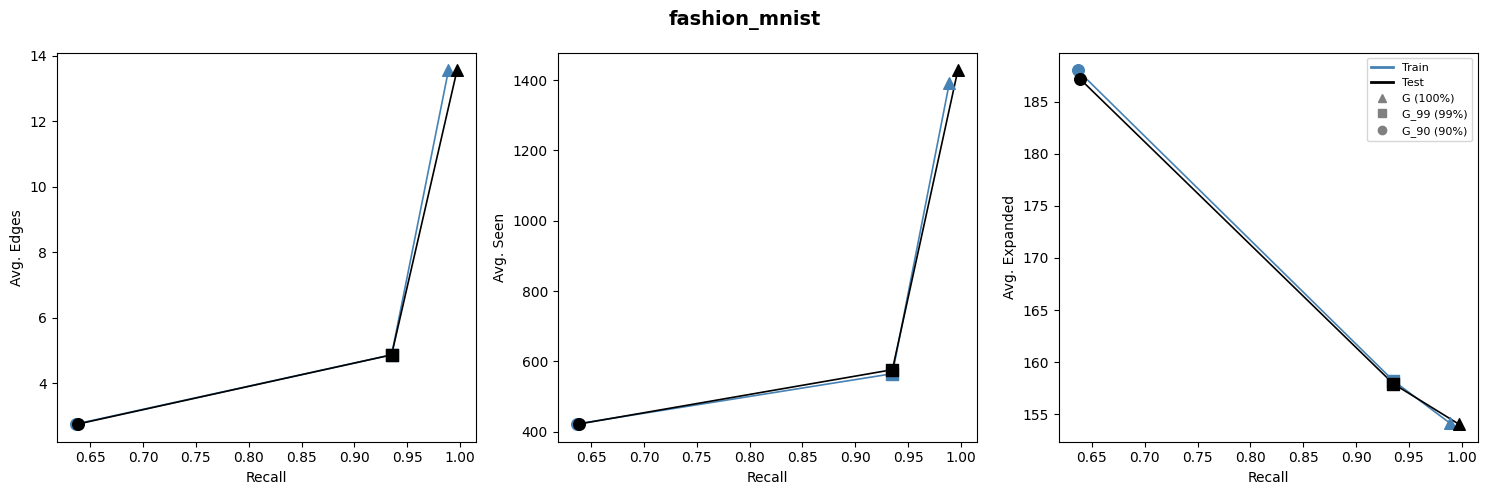

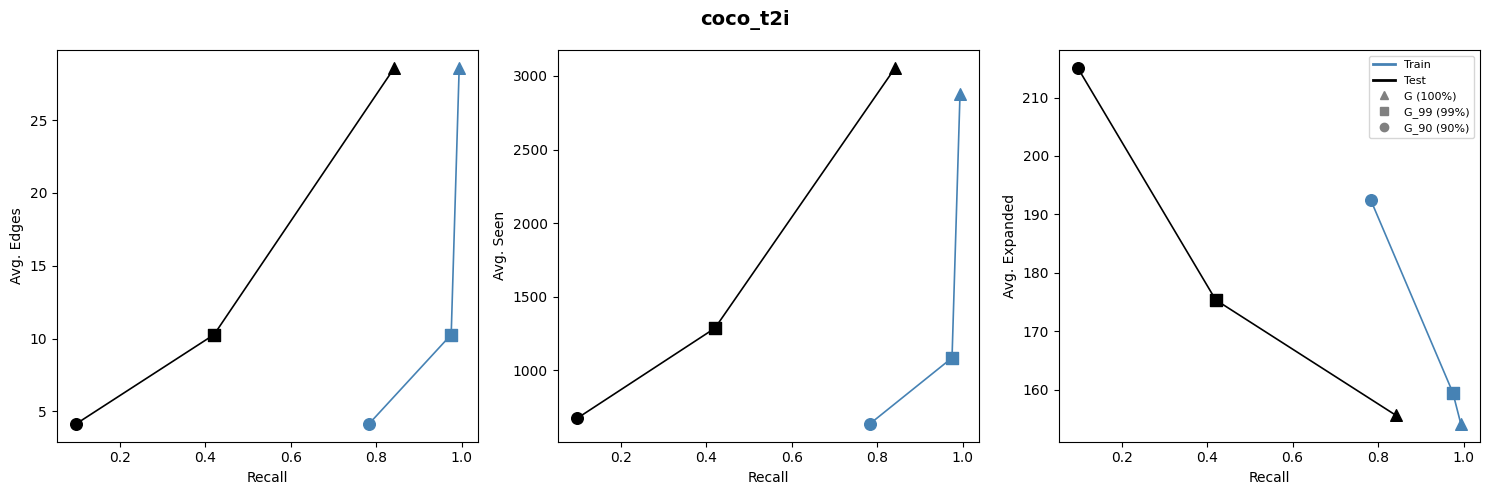

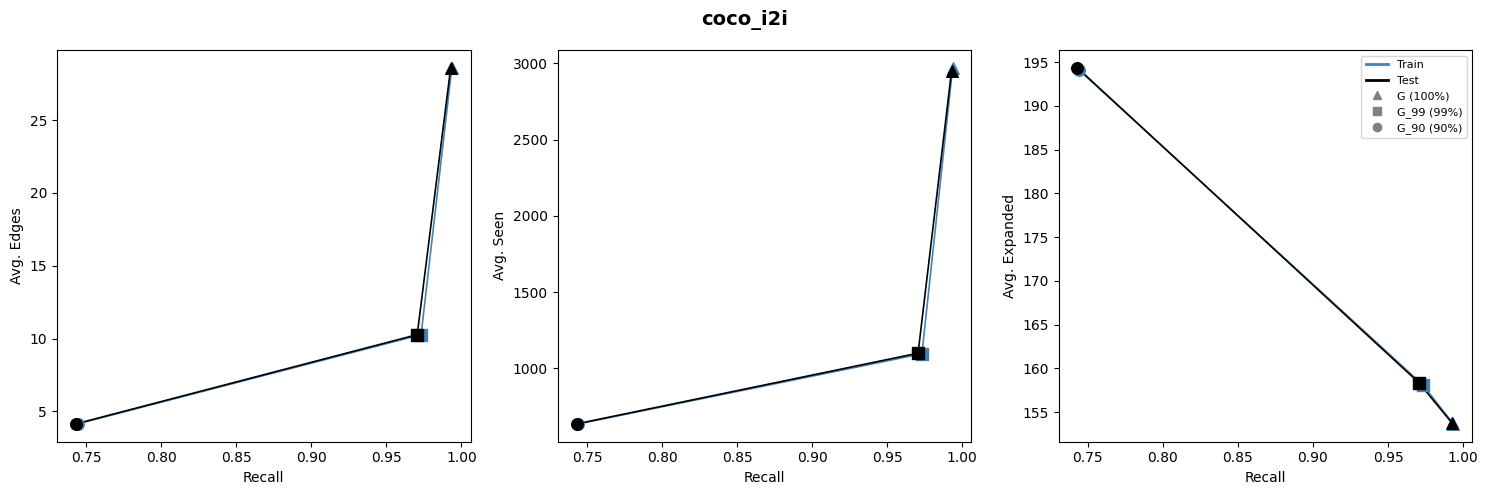

In [16]:
plt.style.use('default')

TRAIN_COLOR = 'steelblue'
TEST_COLOR  = 'black'

for _, row in df.iterrows():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(row['dataset'], fontsize=14, fontweight='bold')

    # y-values are the same for train and test for edges; but seen/expanded differ
    # Rebuild properly
    plot_specs = [
        {
            'ylabel': 'Avg. Edges',
            'train_y': [row['avg_edges_90'],       row['avg_edges_99'],      row['avg_edges']],
            'test_y':  [row['avg_edges_90'],       row['avg_edges_99'],      row['avg_edges']],
            'train_x': [row['train_recall_90'],    row['train_recall_99'],   row['train_recall_G']],
            'test_x':  [row['test_recall_90'],     row['test_recall_99'],    row['test_recall_G']],
        },
        {
            'ylabel': 'Avg. Seen',
            'train_y': [row['train_seen_90'],      row['train_seen_99'],     row['train_seen_G']],
            'test_y':  [row['test_seen_90'],       row['test_seen_99'],      row['test_seen_G']],
            'train_x': [row['train_recall_90'],    row['train_recall_99'],   row['train_recall_G']],
            'test_x':  [row['test_recall_90'],     row['test_recall_99'],    row['test_recall_G']],
        },
        {
            'ylabel': 'Avg. Expanded',
            'train_y': [row['train_expanded_90'],  row['train_expanded_99'], row['train_expanded_G']],
            'test_y':  [row['test_expanded_90'],   row['test_expanded_99'],  row['test_expanded_G']],
            'train_x': [row['train_recall_90'],    row['train_recall_99'],   row['train_recall_G']],
            'test_x':  [row['test_recall_90'],     row['test_recall_99'],    row['test_recall_G']],
        },
    ]

    markers = ['o', 's', '^']   # G_90, G_99, G

    for ax, spec in zip(axes, plot_specs):
        # connecting lines
        ax.plot(spec['train_x'], spec['train_y'], color=TRAIN_COLOR, linewidth=1.2, zorder=1)
        ax.plot(spec['test_x'],  spec['test_y'],  color=TEST_COLOR,  linewidth=1.2, zorder=1)

        # individual markers
        for xi, yi, m in zip(spec['train_x'], spec['train_y'], markers):
            ax.scatter(xi, yi, color=TRAIN_COLOR, marker=m, s=70, zorder=2)
        for xi, yi, m in zip(spec['test_x'], spec['test_y'], markers):
            ax.scatter(xi, yi, color=TEST_COLOR,  marker=m, s=70, zorder=2)

        ax.set_xlabel('Recall')
        ax.set_ylabel(spec['ylabel'])

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color=TRAIN_COLOR, linewidth=2, label='Train'),
        Line2D([0], [0], color=TEST_COLOR,  linewidth=2, label='Test'),
        Line2D([0], [0], color='gray', marker='^', markersize=6, linestyle='none', label='G (100%)'),
        Line2D([0], [0], color='gray', marker='s', markersize=6, linestyle='none', label='G_99 (99%)'),
        Line2D([0], [0], color='gray', marker='o', markersize=6, linestyle='none', label='G_90 (90%)'),
    ]
    axes[-1].legend(handles=legend_handles, loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()